# ***EDA F1***

## 1. Introducción

En este análisis exploratorio me voy a centrar e estudiar cómo los cambios de reglamento han afectado a la competividad en la Fórmula 1. 

Las distintas etapas son las siguientes, con el año en el que comenzaron:

   - 1994 - *Sin electrónica*. Se prohibieron las ayudas electrónicas(suspensión activa, control de tracción)
   - 1998 - *Coches estrechos*.
   - 2009 - *Aerodinámica limpia*.
   - 2014 - *Motores híbridos*.
   - 2017 - *Coches anchos*.
   - 2022 - *Efecto suelo*.
 

#### Objetivos

1. **Dominancia por era**: Identificar qué equipos dominaron cada época y en qué medida
2. **Competitividad**: Analizar qué eras fueron más abiertas o disputadas
3. **Impacto del cambio**: Estudiar si los equipos dominantes caen tras un cambio de reglamento
4. **Extra**: Evaluar la ventaja de salir desde la pole position en cada era

# 2. Imports

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import mysql.connector
import warnings

warnings.filterwarnings("ignore")

In [3]:
# Configuración de visualización
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"

# Colores personalizados para las eras
COLORES_ERAS = {
    "1994-1997: Sin electrónica": "#e41a1c",
    "1998-2008: Coches estrechos": "#377eb8",
    "2009-2013: Aero limpia": "#4daf4a",
    "2014-2016: Híbridos": "#630d71",
    "2017-2021: Coches anchos": "#effd22",
    "2022-2023: Efecto suelo": "#C649D6"
}

# 3. Carga de datos

Conexión con mysql

In [4]:
con = mysql.connector.connect(user = "root", password = "1234", host = "127.0.0.1")
cursor = con.cursor()

In [5]:
cursor.execute("USE f1_db")

Cargar tablas en dataframes

In [6]:
df_resultado = pd.read_sql("SELECT * FROM RESULTADO", con)
df_carrera = pd.read_sql("SELECT * FROM CARRERA WHERE raceYear >= 1994", con)
df_equipo = pd.read_sql("SELECT * FROM EQUIPO", con)
df_piloto = pd.read_sql("SELECT * FROM PILOTO", con)
df_clasificacion = pd.read_sql("SELECT * FROM CLASIFICACION", con)


In [7]:
df_resultado.head()

,resultId,raceId,driverId,constructorId,grid,positionResult,points,laps,totalTime
0,1,18,1,1,1.0,1.0,10.0,58,1:34:50.616
1,2,18,2,2,5.0,2.0,8.0,58,+5.478
2,3,18,3,3,7.0,3.0,6.0,58,+8.163
3,4,18,4,4,11.0,4.0,5.0,58,+17.181
4,5,18,5,1,3.0,5.0,4.0,58,+18.014


In [8]:
df_carrera.head()

,raceId,raceYear,raceRound,circuitId,raceName,raceDate,raceTime,url
0,1,2009,1,1,Australian Grand Prix,2009-03-29,0 days 06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,0 days 09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...
2,3,2009,3,17,Chinese Grand Prix,2009-04-19,0 days 07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...
3,4,2009,4,3,Bahrain Grand Prix,2009-04-26,0 days 12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...
4,5,2009,5,4,Spanish Grand Prix,2009-05-10,0 days 12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...


In [9]:
df_equipo.head()

,constructorId,constructorRef,constructorName,nationality,url
0,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren
1,2,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber
2,3,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...
3,4,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...
4,5,toro_rosso,Toro Rosso,Italian,http://en.wikipedia.org/wiki/Scuderia_Toro_Rosso


In [10]:
df_piloto.head()

,driverId,driverRef,driverNumber,driverCode,forename,surname,dob,nationality,url
0,1,hamilton,44.0,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
1,2,heidfeld,NaN,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld
2,3,rosberg,6.0,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg
3,4,alonso,14.0,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso
4,5,kovalainen,NaN,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen


In [11]:
df_clasificacion.head()

,qualifyingId,raceId,driverId,constructorId,qualifyingPosition,q1,q2,q3
0,1,18,1,1,1,1:26.572,1:25.187,1:26.714
1,2,18,9,2,2,1:26.103,1:25.315,1:26.869
2,3,18,5,1,3,1:25.664,1:25.452,1:27.079
3,4,18,13,6,4,1:25.994,1:25.691,1:27.178
4,5,18,2,2,5,1:25.960,1:25.518,1:27.236


Merge de tablas

In [12]:
df = df_resultado.merge(df_carrera[["raceId", "raceYear", "raceName"]], on="raceId")
df = df.merge(df_equipo[["constructorId", "constructorName"]], on="constructorId")
df = df.merge(df_piloto[["driverId", "forename", "surname"]], on="driverId")

# Juntar Nombre y apellido
df["driver_name"] = df["forename"] + " " + df["surname"]

# 4. Preparación de los datos

In [13]:
print(df.isnull().sum)

<bound method DataFrame.sum of        resultId  raceId  driverId  constructorId   grid  positionResult  \
0         False   False     False          False  False           False   
1         False   False     False          False  False           False   
2         False   False     False          False  False           False   
3         False   False     False          False  False           False   
4         False   False     False          False  False           False   
...         ...     ...       ...            ...    ...             ...   
12812     False   False     False          False   True           False   
12813     False   False     False          False   True           False   
12814     False   False     False          False   True           False   
12815     False   False     False          False   True           False   
12816     False   False     False          False   True           False   

       points   laps  totalTime  raceYear  raceName  constructorName

Funcion para dividir en las 6 etapas

In [14]:
def asignar_etapa(year):
    if(year < 1998):
        return "1994-1997: Sin electrónica"
    elif year < 2009:
        return "1998-2009: Coches estrechos"
    elif year < 2014:
        return "2009-2013: Aero limpia"
    elif year < 2017:
        return "2014-2016: Híbridos"
    elif year < 2022:
        return "2017-2021: Coches anchos"
    else:
        return "2022-2025: Efecto suelo"


In [15]:
df["etapa"] = df["raceYear"].apply(asignar_etapa)

In [16]:
df["etapa"].value_counts()

etapa
1998-2009: Coches estrechos    4004
2009-2013: Aero limpia         2150
2017-2021: Coches anchos       2020
2022-2025: Efecto suelo        1818
1994-1997: Sin electrónica     1578
2014-2016: Híbridos            1247
Name: count, dtype: int64

# 5. Dominancia por etapa

En este punto me voy a centrar en analizar que equipo dominó cada etapa y cómo de dominante fue cons respecto a sus competidores.

In [17]:
df_victorias = df[df["positionResult"] == 1]

print(f"Total victorias: {len(df_victorias)}")

Total victorias: 600


In [18]:
# Victorias por equipo y era
victorias_equipo_era = df_victorias.groupby(["etapa", "constructorName"]).size().reset_index(name="victorias")
victorias_equipo_era.head(10)

,etapa,constructorName,victorias
0,1994-1997: Sin electrónica,Benetton,20
1,1994-1997: Sin electrónica,Ferrari,10
2,1994-1997: Sin electrónica,Ligier,1
3,1994-1997: Sin electrónica,McLaren,3
4,1994-1997: Sin electrónica,Williams,32
5,1998-2009: Coches estrechos,BMW Sauber,1
6,1998-2009: Coches estrechos,Ferrari,96
7,1998-2009: Coches estrechos,Honda,1
8,1998-2009: Coches estrechos,Jordan,4
9,1998-2009: Coches estrechos,McLaren,55


In [19]:
# Equipo dominante de cada era
dominantes = victorias_equipo_era.loc[victorias_equipo_era.groupby("etapa")["victorias"].idxmax()]
dominantes = dominantes.sort_values("etapa")
print(dominantes)

                          etapa constructorName  victorias
4    1994-1997: Sin electrónica        Williams         32
6   1998-2009: Coches estrechos         Ferrari         96
19       2009-2013: Aero limpia        Red Bull         47
22          2014-2016: Híbridos        Mercedes         51
28     2017-2021: Coches anchos        Mercedes         60
34      2022-2025: Efecto suelo        Red Bull         54


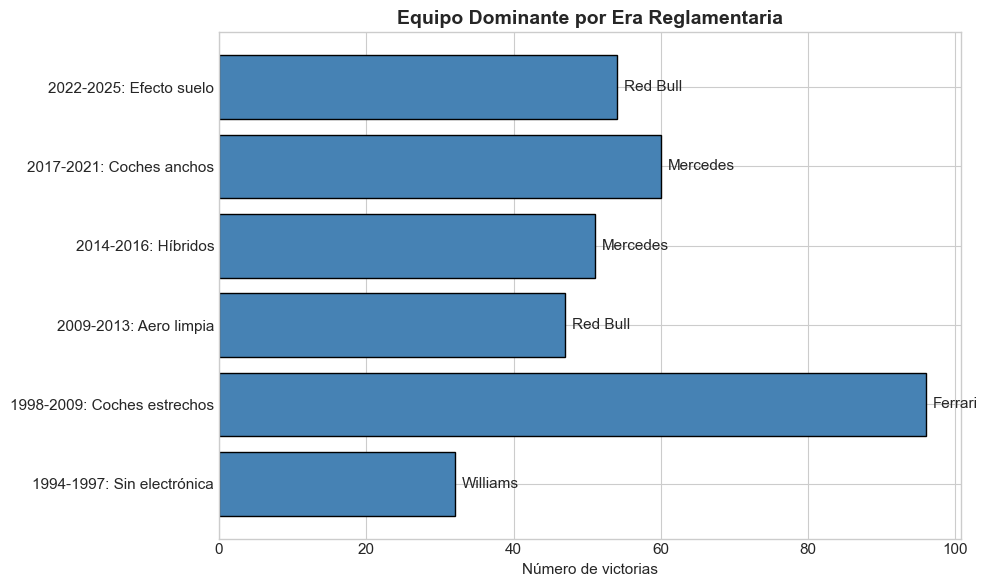

In [20]:
plt.figure(figsize=(10, 6))
plt.barh(dominantes["etapa"], dominantes["victorias"], color="steelblue", edgecolor="black")
plt.xlabel("Número de victorias")
plt.title("Equipo Dominante por Era Reglamentaria")

# Añadir nombre del equipo en cada barra
for i, row in dominantes.iterrows():
    plt.text(row["victorias"] + 1, row["etapa"], row["constructorName"], va="center")

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(dominantes["etapa"], dominantes["victorias"], color="steelblue", edgecolor="black")
plt.xlabel("Número de victorias")
plt.title("Equipo Dominante por Era Reglamentaria")

# Añadir nombre del equipo en cada barra
for i, row in dominantes.iterrows():
    plt.text(row["victorias"] + 1, row["etapa"], row["constructorName"], va="center")

plt.tight_layout()
plt.show()

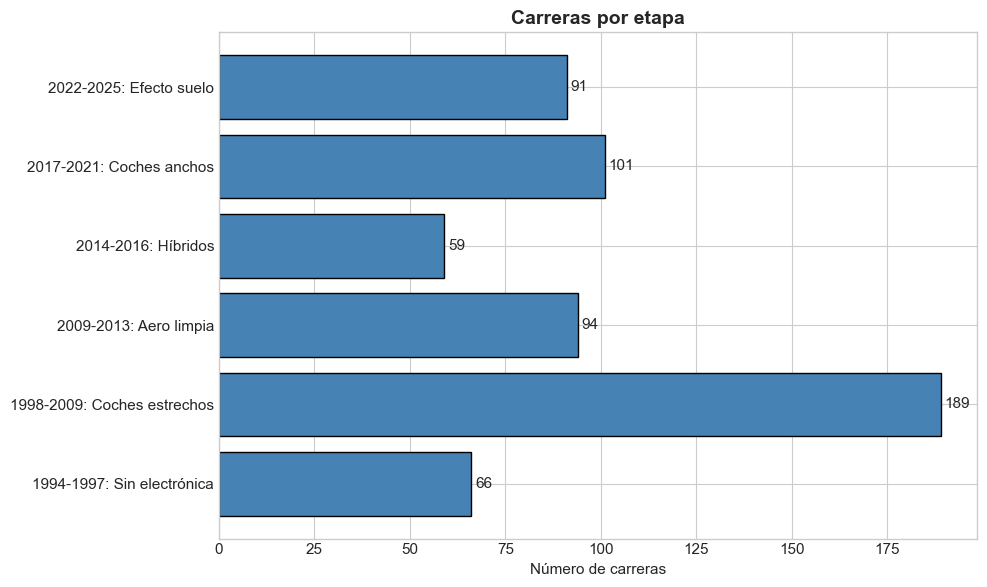

In [22]:
carreras_etapa = df_victorias.groupby("etapa").size().reset_index(name = "carreras")
carreras_etapa = carreras_etapa.sort_values("etapa")

plt.figure(figsize = (10, 6))
plt.barh(carreras_etapa["etapa"], carreras_etapa["carreras"], color = "steelblue", edgecolor = "black")
plt.xlabel("Número de carreras")
plt.title("Carreras por etapa")

for i, row in carreras_etapa.iterrows():
    plt.text(row["carreras"] + 1, row["etapa"], str(row["carreras"]), va = "center")

plt.tight_layout()
plt.show()

In [23]:
# Calcular porcentaje de victorias del equipo dominante
dominantes["total_carreras"] = dominantes["etapa"].map(carreras_etapa.set_index("etapa")["carreras"])
dominantes["porcentaje"] = (dominantes["victorias"] / dominantes["total_carreras"] * 100).round(1)

print(dominantes[["etapa", "constructorName", "victorias", "total_carreras", "porcentaje"]])

                          etapa constructorName  victorias  total_carreras  \
4    1994-1997: Sin electrónica        Williams         32              66   
6   1998-2009: Coches estrechos         Ferrari         96             189   
19       2009-2013: Aero limpia        Red Bull         47              94   
22          2014-2016: Híbridos        Mercedes         51              59   
28     2017-2021: Coches anchos        Mercedes         60             101   
34      2022-2025: Efecto suelo        Red Bull         54              91   

    porcentaje  
4         48.5  
6         50.8  
19        50.0  
22        86.4  
28        59.4  
34        59.3  


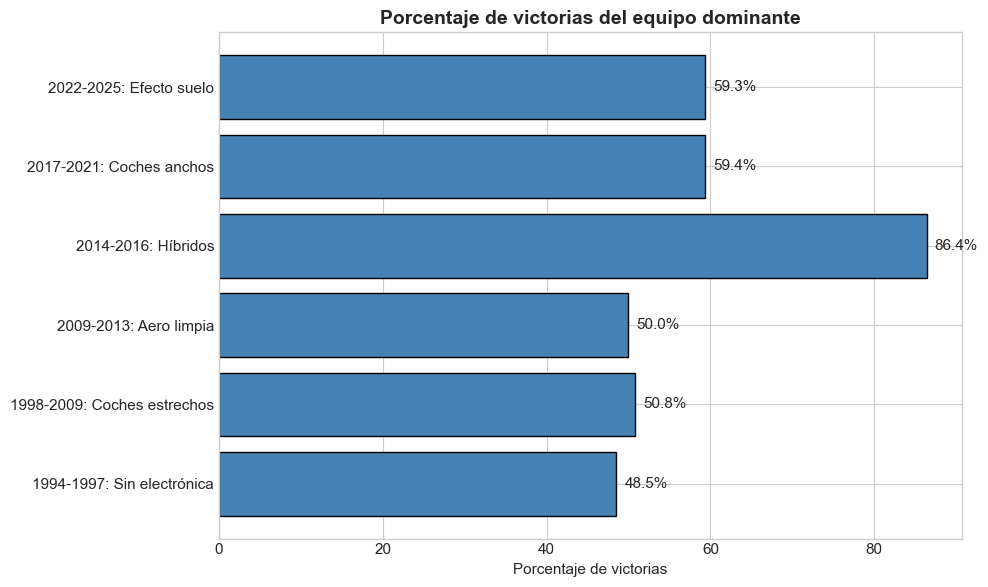

In [24]:
plt.figure(figsize = (10, 6))
plt.barh(dominantes["etapa"], dominantes["porcentaje"], color = "steelblue", edgecolor = "black")
plt.xlabel("Porcentaje de victorias")
plt.title("Porcentaje de victorias del equipo dominante")

for i, row in dominantes.iterrows():
    plt.text(row["porcentaje"] + 1, row["etapa"], f'{row["porcentaje"]}%', va = "center")

plt.legend()
plt.tight_layout()
plt.show()

In [25]:
# Top 3 equipos por etapa
top3_etapa = victorias_equipo_etapa.groupby("etapa").apply(
    lambda x: x.nlargest(3, "victorias")
).reset_index(drop=True)

top3_etapa.head(12)

NameError: name 'victorias_equipo_etapa' is not defined

victorias por año

In [26]:
# Victorias por año y equipo
victorias_año = df_victorias.groupby(["raceYear", "constructorName"]).size().reset_index(name="victorias")

# Top 5 equipos históricos
top_equipos = df_victorias["constructorName"].value_counts().head(5).index.tolist()
victorias_año_top = victorias_año[victorias_año["constructorName"].isin(top_equipos)]

victorias_año_top.head()

,raceYear,constructorName,victorias
1,1994,Ferrari,1
2,1994,Williams,7
4,1995,Ferrari,1
5,1995,Williams,5
6,1996,Ferrari,3


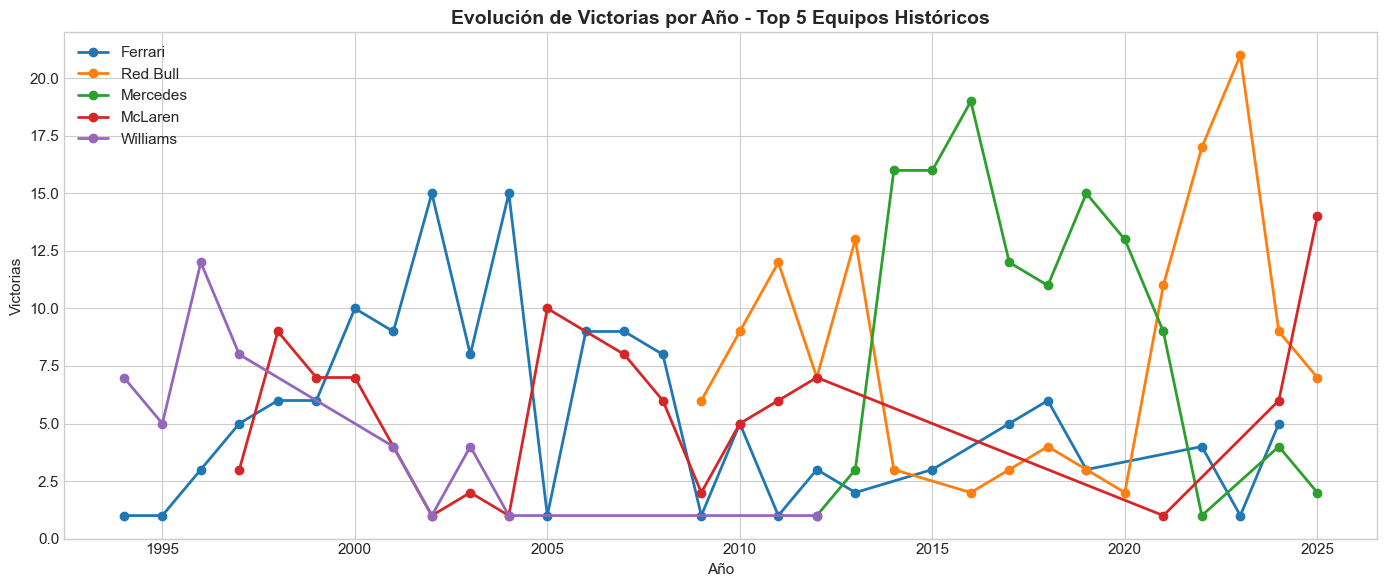

In [27]:
plt.figure(figsize=(14, 6))

for equipo in top_equipos:
    datos = victorias_año_top[victorias_año_top["constructorName"] == equipo]
    plt.plot(datos["raceYear"], datos["victorias"], marker="o", label=equipo, linewidth=2)

plt.xlabel("Año")
plt.ylabel("Victorias")
plt.title("Evolución de Victorias por Año - Top 5 Equipos Históricos")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()